# House Price prediction Using Machine Learning

# 1.Project Overview

This Project aims to predict house based on property features such as area,
bedrooms,bathrooms,floors,year built, location, condition , and garage
availability.Machine Learning techniques are used to build predictive models that
estimate house prices accurately.

# 2 Problem Statement

House prices are influenced by multiple factors.Manually estimating property prices can be 
difficult and inaccurate.The objective of this project is to develop a machine learning model
the can predict house prices based on various property characteristics.

# 3. Objectives

- Analysis housing data.
- perform data cleaning an preprocessing.
- Explore relationships between features and house prices.
- Build machine learning models.
- Compare model performance.
- Predict house prices accurately.

# 4. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 5.Load Dataset

In [2]:
df = pd.read_csv('House Price Prediction Dataset.csv')

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# 6. Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [5]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


# 7. Data Cleaning

Check  Missing Values

In [7]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

 Remove Missing Value

In [10]:
df = df.dropna()


Remove Dupllicate Records

In [11]:
df = df.drop_duplicates()

# 8. Exploratory Data Analysis (EDA)

Price Distribution

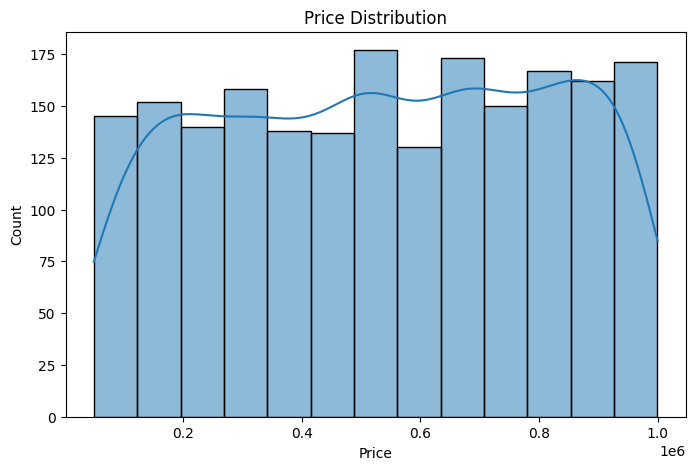

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde = True)
plt.title("Price Distribution")
plt.show()

Area vs Price

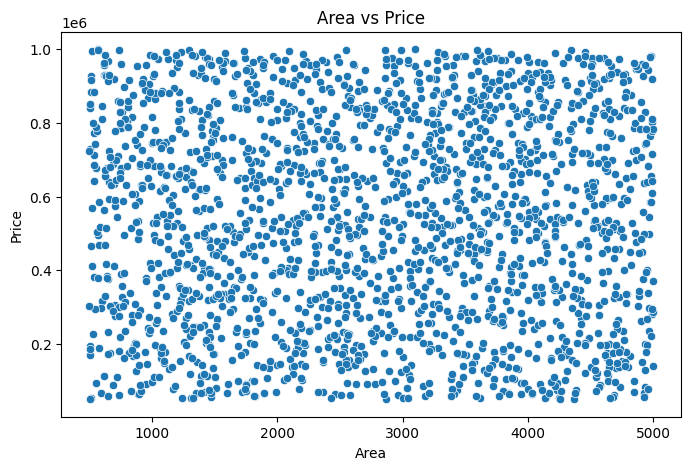

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Area',
    y = 'Price',
    data = df
)
plt.title("Area vs Price")
plt.show()

Bedrooms vs Price

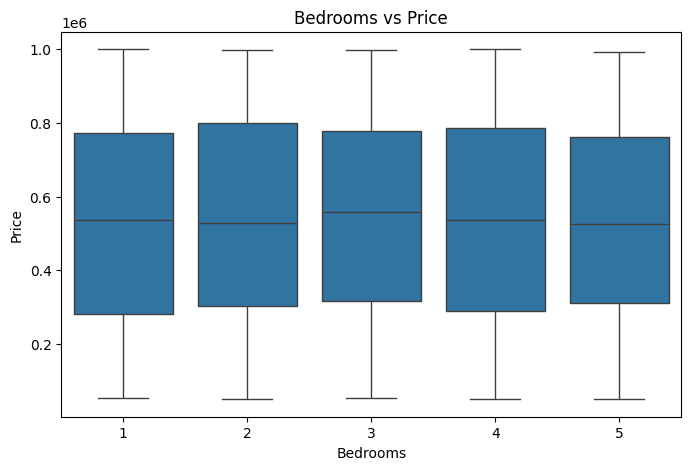

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x = 'Bedrooms',
    y = 'Price',
    data = df
)
plt.title("Bedrooms vs Price")
plt.show()

# 9. Correlation Heatmap

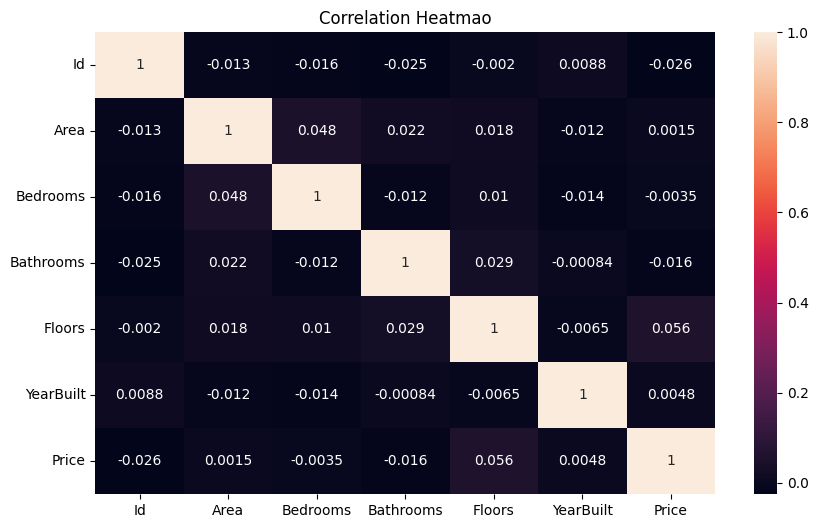

In [18]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.title("Correlation Heatmao")
plt.show()

# 10.Features Engineering

Convert Garage Values

In [19]:
df['Garage'] = df['Garage'].map({
    'Yes':1,
    'No':0
})

One-Hot Encoding

In [20]:
df = pd.get_dummies(
    df,
    columns=['Location','Condition'],
    drop_first=True
)

# 11.Feature Selection

In [21]:
x = df.drop(['Id','Price'], axis = 1)
y = df['Price']

# 12.Train-Test Split

In [22]:
x_train, x_test, y_train ,y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state=42
)

# 13. Linear Regression Model

In [23]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

# 14 Random Forest Regressor

In [37]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

# 15.Model Evaluation

Linear Regression

In [29]:
print("MAE:",mean_absolute_error(y_test,lr_pred))
print("MSE:",mean_squared_error(y_test,lr_pred))
print("R2:",r2_score(y_test,lr_pred))

MAE: 243241.97758826384
MSE: 78321466146.0328
R2: -0.006717808430749761


Random Forest

In [38]:
print("MAE:",mean_absolute_error(y_test,rf_pred))
print("MSE:",mean_squared_error(y_test,rf_pred))
print("R2:",r2_score(y_test,rf_pred))

MAE: 252565.09977500004
MSE: 85272606092.7058
R2: -0.09606542559821163


# 16.Actual vs Predicted Prices

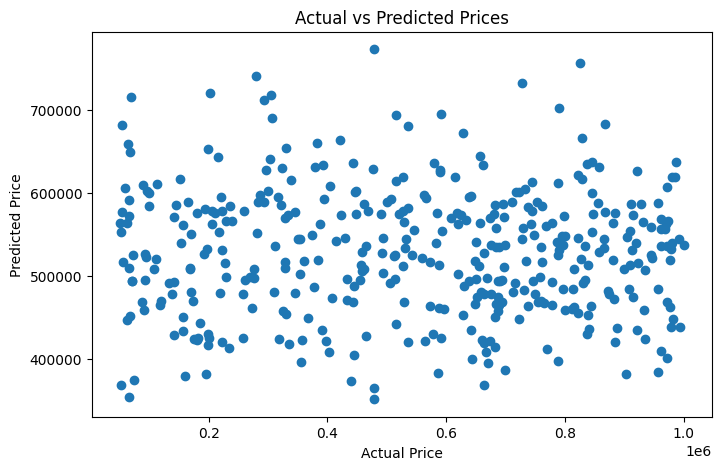

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

# 17.House Price Prediction

In [41]:
sample_house = x.iloc[[0]]

prediction = rf.predict(sample_house)

print("Predicted House Price:",prediction[0])

Predicted House Price: 278582.35


# 18.Conclusion

1] House price is highly influenced by the area of the property.
2] Houses with more bedrooms and bathrooms generally have higher prices.
3] Location plays an important role in determining houses prices.
4] Properties with garage facilities usually have higher price compared to a garage.
5] Houses in better condition tend to have higher market value.
6] Newer housews(recently bulit) often have higher prices than older houses.
7] Multi-floor houses may have higher prices due to additional living space.
8] Differeent housing features contribute differently to price prediction.
9] The dataset contains both numerical and categorical variables . making it suitable for machine learning analysis.
10] Data visualization helped identify relationships between property features and house prices.
11] Machine learning models can effectively predict house price using the available features.
12] Machine learning models can effectively predict house priece using the available features.